# 🌍 CarbonGlobe — Data Tutorial & Baseline

**CarbonGlobe** is a global-scale, ML-ready dataset for forecasting the **forest carbon cycle**.
It emulates the theory-based **Ecosystem Demography (ED) v3.0** model, which is computationally
expensive to run at global scale. The goal is to train ML emulators that, given environmental
drivers and an initial forest state, forecast key carbon variables over **40 years**.

```bibtex
@article{wang2025carbonglobe,
  title={CarbonGlobe: A Global-Scale, Multi-Decade Dataset and Benchmark for Carbon Forecasting in Forest Ecosystems},
  author={Wang, Zhihao and Ma, Lei and Hurtt, George and Jia, Xiaowei and Li, Yanhua and Li, Ruohan and Li, Zhili and Xu, Shuo and Xie, Yiqun},
  journal={Advances in Neural Information Processing Systems},
  volume={38},
  year={2025}
}
```
This notebook walks through:
1. Loading the train / val / test split.
2. Normalizing the data with the provided statistics.
3. Visualizing data points on 2D global maps (using the 2D mask).
4. Training a **Random Forest** one-step-ahead baseline.
5. Computing evaluation metrics: **RMSE, MAE, R²**, plus the problem-driven **delta** and
   **cumulative** errors.


## 1. The forecasting task & data layout

For every **land site** (54,152 of them worldwide, on a 0.5° grid) and every **seed tree age**
(15 ages), ED produces a 40-year sequence of 7 carbon-related outputs from monthly environmental
inputs. The ML task:

> Given a year's 12-month input sequence **X** and the **initial target vector v** (last year's
> 7 outputs), forecast this year's 7 outputs. Repeat autoregressively for 40 years.

### Two levels of data (for two purposes)

CarbonGlobe ships the data at two levels — pick the one that fits what you're doing:

**① ML-ready train/test file — for model training.**
`data_global/res_train4_test8.npz` bundles the sites you train on together with a small, fixed
held-out test set, so you don't have to index the ~14 GB global arrays yourself. This is what the
challenge's benchmark models train and are evaluated on:

| Array | Shape | Meaning |
|---|---|---|
| `x_train` / `y_train` | `(3373,40,12,136)` / `(15,3373,41,12,7)` | the **train + val** sites (3035 + 338) |
| `x_test` / `y_test` | `(852,40,12,136)` / `(15,852,41,12,7)` | **test8** — an 852-site held-out test set (a **subset of the global `test.csv` sites**) |

**② Global grid — for global-scale evaluation & downstream applications.**
The full `(54152, …)` arrays cover *every* land site on the 0.5° grid. Use them to score a trained
model across the whole planet, make spatial maps, or drive downstream/regional analyses. Slice them
with the `train.csv / val.csv / test.csv` **site indices**, which **partition** the 54,152 sites.

| File | Shape | Meaning |
|---|---|---|
| `data_global/glob_X_fea.npy` | `(54152, 40, 12, 136)` | global inputs: site × year × month × **136 features** |
| `data_global/glob_Y{age}.npy` | `(54152, 41, 12, 7)` | global outputs for a seed age: site × year(0=init) × month × **7 targets** |
| `train.csv / val.csv / test.csv` | — | disjoint **site indices**: 3035 / 338 / 50779 |

Both levels use the **same split**: `test8` ⊂ `test.csv`, and training never sees a test site. The
deep-learning baselines train on `res_train4_test8.npz` and report their headline scores on
**test8**; the Random Forest below instead builds its train/test **straight from the global arrays
via the CSV indices** — either route respects the same held-out split.

**Shared files** (`data_stats/`): `data_stats.npz` (`x_mean,x_std` (136), `y_mean,y_std` (7) for
normalization), `age_triplet.npz` (`age` (15), `age_mean`,`age_slope` (15×7) per-age priors),
`mask2d.npy` (`(360,720)`, maps the 54,152 sites onto the global grid).

**7 target variables:** `height` (canopy height), `agb` (above-ground biomass), `soil` (soil carbon),
`lai` (leaf area index), `gpp`, `npp`, `rh` (gross/net primary productivity & heterotrophic respiration).


In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Configuration: point this at the dataset folder ---
# Local layout: notebook lives in tutorials/, data in ../datasets/
# On Kaggle, set e.g. DATA_DIR = Path('/kaggle/input/carbonglobe')
DATA_DIR = Path(os.environ.get('CARBONGLOBE_DATA', '../data/'))
GLOB_DIR = DATA_DIR / 'data_global'
STAT_DIR = DATA_DIR / 'data_stats'

TREE_BAND = ['height', 'agb', 'soil', 'lai', 'gpp', 'npp', 'rh']
AGES = [1, 10, 20, 30, 50, 70, 100, 150, 200, 250, 300, 350, 400, 450, 500]
N_SITE, N_YEAR, N_MONTH, N_FEA, N_OUT = 54152, 40, 12, 136, 7

print('Data dir :', DATA_DIR.resolve())
print('Targets  :', TREE_BAND)
print('Seed ages:', AGES)


Data dir : E:\kaggle\ieee2026_ecosystem_forecast\data
Targets  : ['height', 'agb', 'soil', 'lai', 'gpp', 'npp', 'rh']
Seed ages: [1, 10, 20, 30, 50, 70, 100, 150, 200, 250, 300, 350, 400, 450, 500]


In [2]:
# --- Load normalization stats, age priors, and the 2D mask ---
stats = np.load(STAT_DIR / 'data_stats.npz')
X_MEAN, X_STD = stats['x_mean'], stats['x_std']          # (136,)
Y_MEAN, Y_STD = stats['y_mean'], stats['y_std']          # (7,)

age_tri = np.load(STAT_DIR / 'age_triplet.npz')
TRI_AGE, TRI_MEAN, TRI_SLOPE = age_tri['age'], age_tri['age_mean'], age_tri['age_slope']

mask2d = np.load(STAT_DIR / 'mask2d.npy')                # (360, 720)
mask_bool = mask2d.astype(bool)
print('x_mean/x_std:', X_MEAN.shape, '| y_mean/y_std:', Y_MEAN.shape)
print('age triplet :', TRI_AGE.shape, TRI_MEAN.shape, TRI_SLOPE.shape)
print('mask2d      :', mask2d.shape, '| valid sites =', int(mask_bool.sum()))
pd.DataFrame({'target': TREE_BAND, 'y_mean': Y_MEAN, 'y_std': Y_STD})


x_mean/x_std: (136,) | y_mean/y_std: (7,)
age triplet : (15,) (15, 7) (15, 7)
mask2d      : (360, 720) | valid sites = 54152


,target,y_mean,y_std
0,height,10.906445,10.370706
1,agb,3.395674,5.240912
2,soil,6.242140,6.250174
3,lai,1.882692,2.172708
4,gpp,1.081003,1.483502
5,npp,0.523387,0.724595
6,rh,0.489000,0.625075


In [3]:
# --- Load the train / val / test site indices ---
train_idx = pd.read_csv(DATA_DIR / 'train.csv', header=None)[0].values
val_idx   = pd.read_csv(DATA_DIR / 'val.csv',   header=None)[0].values
test_idx  = pd.read_csv(DATA_DIR / 'test.csv',  header=None)[0].values
print(f'train sites: {len(train_idx):>6}')
print(f'val sites  : {len(val_idx):>6}')
print(f'test sites : {len(test_idx):>6}')
print(f'total      : {len(train_idx)+len(val_idx)+len(test_idx):>6} / {N_SITE}')


train sites:   3035
val sites  :    338
test sites :  50779
total      :  54152 / 54152


## 2. Loading data efficiently (memory-mapping)

`glob_X_fea.npy` is ~14 GB, so we **never load it fully**. `np.load(..., mmap_mode='r')` opens it
on disk; fancy-indexing with a list of site indices pulls only those rows into RAM.


In [4]:
# Memory-map the big input array; load only what we index.
X = np.load(GLOB_DIR / 'glob_X_fea.npy', mmap_mode='r')   # (54152, 40, 12, 136)
print('X (mmap):', X.shape, X.dtype)

def load_Y(age):
    '''Load the output array for a given seed age, memory-mapped.'''
    return np.load(GLOB_DIR / f'glob_Y{age:03d}.npy', mmap_mode='r')  # (54152, 41, 12, 7)

Y100 = load_Y(100)
print('Y100 (mmap):', Y100.shape, Y100.dtype)

# Peek at one training site/age: its 40-year December trajectory of each target.
s = int(train_idx[0])
# use Dec. for Y in all experiments
traj = Y100[s, 1:, 11, :]    # years 1..40, December, all targets -> (40, 7) 
print('Example site', s, 'age 100, Dec trajectory shape:', traj.shape)
pd.DataFrame(traj, columns=TREE_BAND, index=pd.RangeIndex(1, 41, name='year')).head()


X (mmap): (54152, 40, 12, 136) float32
Y100 (mmap): (54152, 41, 12, 7) float32
Example site 2358 age 100, Dec trajectory shape: (40, 7)


,height,agb,soil,lai,gpp,npp,rh
year,,,,,,,
1,2.102812,0.177204,6.111109,0.030403,-0.000007,-0.000011,0.0
2,2.108166,0.176359,5.994278,0.031034,-0.000010,-0.000122,0.0
3,2.094675,0.041688,6.183030,0.031261,-0.000007,-0.000008,0.0
4,2.097978,0.040193,5.913941,0.031582,-0.000012,-0.000014,0.0
5,2.087357,0.040893,5.671275,0.032050,-0.000011,-0.000016,0.0


## 3. Normalization

All models train in **z-score space** using the provided per-channel statistics:
`z = (x - mean) / (std + 1e-10)`. Metrics are reported back in **physical units** by inverting it.


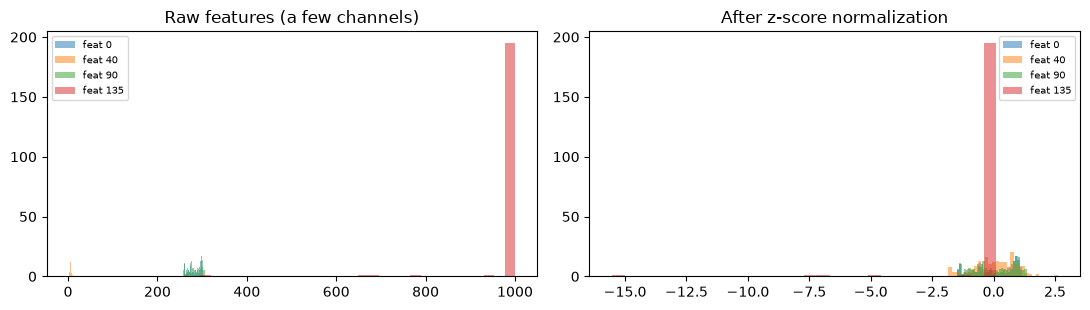

Normalized sample mean ~0, std ~1: 0.006 0.8


In [5]:
def norm_x(a):   return (a - X_MEAN) / (X_STD + 1e-10)
def norm_y(a):   return (a - Y_MEAN) / (Y_STD + 1e-10)
def inv_y(a):    return a * (Y_STD + 1e-10) + Y_MEAN

# Illustrate on a sample of training sites: raw vs normalized feature distributions.
samp = np.sort(np.random.RandomState(0).choice(train_idx, size=200, replace=False))
x_samp = np.asarray(X[samp][:, :, :, :]).mean(axis=(1, 2))   # (200, 136) annual-mean features
x_samp_n = norm_x(x_samp)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
for j in [0, 40, 90, 135]:
    ax[0].hist(x_samp[:, j], bins=30, alpha=0.5, label=f'feat {j}')
    ax[1].hist(x_samp_n[:, j], bins=30, alpha=0.5, label=f'feat {j}')
ax[0].set_title('Raw features (a few channels)'); ax[1].set_title('After z-score normalization')
for a in ax: a.legend(fontsize=7)
plt.tight_layout(); plt.show()
print('Normalized sample mean ~0, std ~1:', x_samp_n.mean().round(3), x_samp_n.std().round(3))


## 4. Visualizing data on 2D global maps

`mask2d` tells us which of the 360×720 grid cells are valid land sites (in site-index order).
The helper below scatters a per-site vector back onto the global grid.


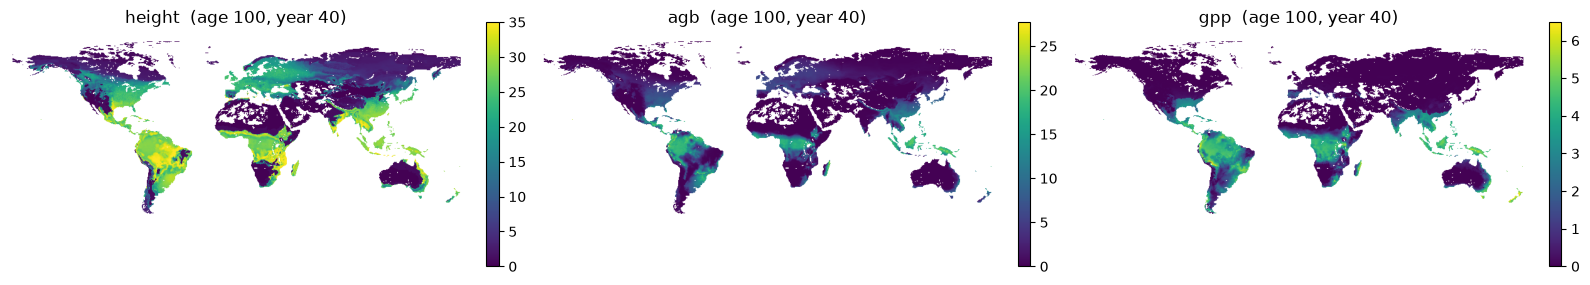

In [6]:
def to_grid(values, idx=None):
    '''Place a per-site vector onto the (360,720) grid. `values` aligns with `idx`
    (defaults to all 54,152 sites in order). Empty cells are NaN.'''
    grid = np.full(mask2d.shape, np.nan, dtype=float)
    flat_pos = np.flatnonzero(mask_bool.ravel())          # site-order positions on the grid
    pos = flat_pos if idx is None else flat_pos[idx]
    grid.ravel()[pos] = values
    return grid

# Global maps of three targets at Year 40 (December), seed age 100, over ALL sites.
year, age = 40, 100
Y = load_Y(age)
dec_year40 = np.asarray(Y[:, year, 11, :])                # (54152, 7)

show = ['height', 'agb', 'gpp']
fig, axes = plt.subplots(1, 3, figsize=(16, 3.4))
for ax, name in zip(axes, show):
    k = TREE_BAND.index(name)
    im = ax.imshow(to_grid(dec_year40[:, k]), cmap='viridis', origin='upper')
    ax.set_title(f'{name}  (age {age}, year {year})'); ax.axis('off')
    fig.colorbar(im, ax=ax, fraction=0.025)
plt.tight_layout(); plt.show()


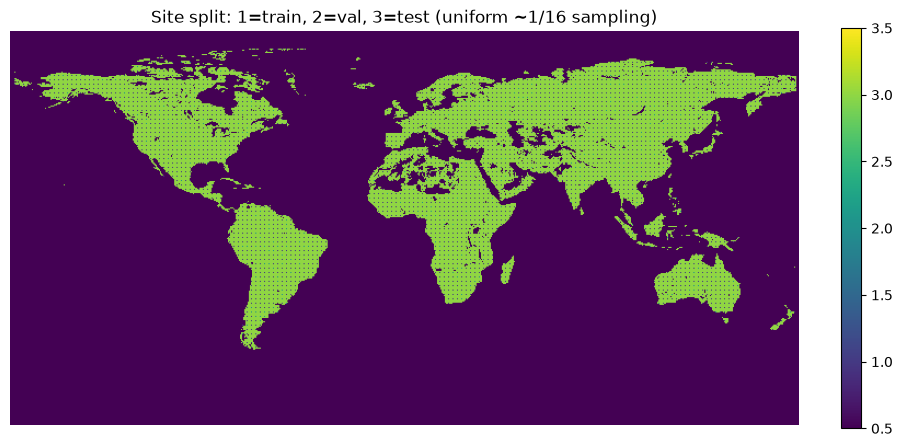

In [7]:
# Where are the train / val / test sites? (uniform 1/16 sampling for training)
plt.figure(figsize=(11, 5.2))
im = plt.imshow(mask2d, origin='upper', vmin=0.5, vmax=3.5)
plt.title('Site split: 1=train, 2=val, 3=test (uniform ~1/16 sampling)'); plt.axis('off')
plt.colorbar(im, fraction=0.025); plt.show()

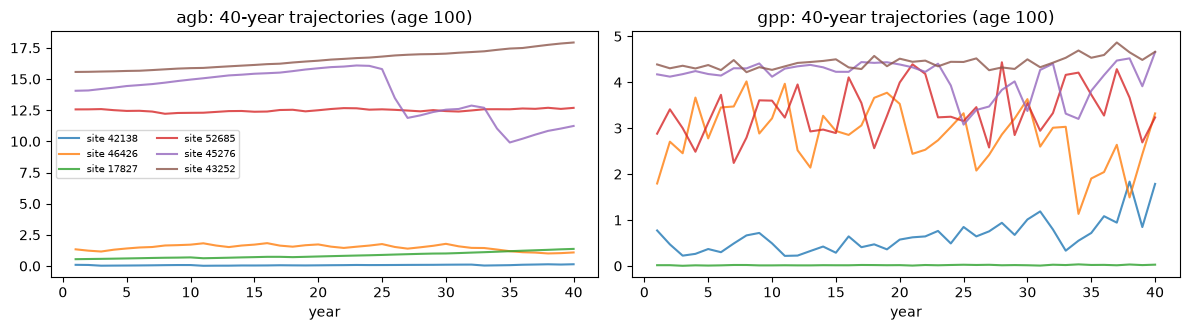

In [8]:
# A few per-site 40-year trajectories (December) for two targets.
sites = np.random.RandomState(1).choice(train_idx, size=6, replace=False)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
for name, ax in zip(['agb', 'gpp'], axes):
    k = TREE_BAND.index(name)
    for s in sites:
        ax.plot(range(1, 41), np.asarray(load_Y(100)[s, 1:, 11, k]), alpha=0.8, label=f'site {s}')
    ax.set_title(f'{name}: 40-year trajectories (age 100)'); ax.set_xlabel('year')
axes[0].legend(fontsize=7, ncol=2); plt.tight_layout(); plt.show()


## 5. A Random Forest baseline (one-step training, autoregressive test)

We build the same **one-step-ahead** supervised problem the benchmark models use:

* **Features (144):** the year's annual-mean inputs (136) ⊕ the initial target vector `v` =
  previous year's December outputs (7) ⊕ the scaled seed age (`age/500`, 1).
* **Target (7):** this year's December outputs.

We train on **all training sites × 15 ages × 40 years** (≈ 1.8M samples), in normalized space,
with a multi-output `RandomForestRegressor`. Training uses the **true** previous-year output as `v`
(teacher forcing); at test time (§6) we instead **roll the model out autoregressively** from `y0`.


In [9]:
def build_one_step(site_idx, ages=AGES, verbose=True):
    '''Construct one-step-ahead (X_feat, Y_target) for the given sites & ages.
    X_feat: annual-mean inputs (136) + init v (7) + age/500 (1) = 144, normalized.
    Y_target: that year's Dec outputs (7), normalized.'''
    site_idx = np.asarray(site_idx)
    Xann = np.asarray(X[site_idx]).mean(axis=2)            # (S, 40, 136) annual-mean inputs
    Xann_n = norm_x(Xann).astype(np.float32)
    feats, targs = [], []
    for a in ages:
        Ydec = np.asarray(load_Y(a)[site_idx][:, :, 11, :])    # (S, 41, 7)
        Ydec_n = norm_y(Ydec).astype(np.float32)
        age_col = np.full((len(site_idx), 1), a / 500.0, dtype=np.float32)
        for t in range(1, N_YEAR + 1):                          # forecast years 1..40
            f = np.concatenate([Xann_n[:, t - 1, :],            # year-t inputs
                                Ydec_n[:, t - 1, :],            # init v (year t-1)
                                age_col], axis=1)               # (S, 144)
            feats.append(f); targs.append(Ydec_n[:, t, :])      # target year t
    Xf = np.concatenate(feats, 0); Yt = np.concatenate(targs, 0)
    if verbose: print(f'  built {Xf.shape[0]:,} samples x {Xf.shape[1]} feats from {len(site_idx)} sites')
    return Xf, Yt

print('Building training set (all train sites, all ages, all years)...')
Xtr, Ytr = build_one_step(train_idx)
print('X_train', Xtr.shape, Xtr.dtype, '| Y_train', Ytr.shape)


Building training set (all train sites, all ages, all years)...
  built 1,821,000 samples x 144 feats from 3035 sites
X_train (1821000, 144) float32 | Y_train (1821000, 7)


In [10]:
from sklearn.ensemble import RandomForestRegressor
import joblib, time

# Save the fitted model so it can be reloaded for autoregressive testing without retraining.
MODEL_PATH = Path('../models/rf_baseline.joblib')

if MODEL_PATH.exists():
    rf = joblib.load(MODEL_PATH)
    print('Loaded saved Random Forest from', MODEL_PATH.resolve())
else:
    # Full baseline over ~1.8M samples. max_samples bags each tree on a subset for tractable
    # training while still using all sites; tune n_estimators/depth as compute allows.
    rf = RandomForestRegressor(
        n_estimators=100, max_depth=18, min_samples_leaf=20,
        max_samples=0.3, n_jobs=-1, random_state=0)
    t0 = time.time()
    rf.fit(Xtr, Ytr)
    print(f'Random Forest trained in {(time.time()-t0)/60:.1f} min on {Xtr.shape[0]:,} samples.')
    joblib.dump(rf, MODEL_PATH, compress=3)
    print('Saved ->', MODEL_PATH.resolve())

Loaded saved Random Forest from E:\kaggle\ieee2026_ecosystem_forecast\models\rf_baseline.joblib


## 6. Evaluation metrics (autoregressive rollout)

For a **fair comparison** with the deep emulators, we evaluate the Random Forest the *same way*
they are tested: a **40-year autoregressive rollout** on the **test8 held-out set** (the 852 ML test
sites in `res_train4_test8.npz`). We provide **only the year-0 initial state `y0`**, then feed the
model's own prediction back as the next year's init `v` — errors therefore **accumulate** over the
horizon, exactly as the benchmark emulators are evaluated. (The per-site map afterward then
visualizes error across the full global grid — the §1-② global-scale view.)

> This is the key difference from training. We *train* one-step-ahead with the true previous-year
> output (teacher forcing), but at *test* time the truth is unavailable beyond `y0`, so the model
> must consume its own forecasts. (The deep models add an extra design — clamping height to 0 at
> bare-ground sites — which we omit here so the RF rollout is pure feedback.)

We report, in **physical units**, per target:
* **RMSE**, **MAE**, **R²** — standard step-wise metrics.
* **Delta error** — RMSE of the year-over-year *change* `(Yt−Yt−1) − (Ŷt−Ŷt−1)`; reflects how well
  inter-annual variations are captured (matches the values reported in the paper's tables).
* **Cumulative error** — RMSE at the final year `Y_T − Ŷ_T`; reflects long-horizon drift.

Expect the autoregressive numbers to be **substantially worse** than a teacher-forced one-step
readout — that gap *is* the long-horizon drift the benchmark is designed to expose.


In [11]:
def rollout_rf(model, Xann_n, Ydec_by_age, ages=AGES, verbose=True):
    '''Autoregressive 40-year rollout for the RF, given ONLY the year-0 init state y0.
    Xann_n: (S,40,136) normalized annual-mean inputs.
    Ydec_by_age: (A,S,41,7) PHYSICAL December targets aligned with `ages` (year 0 = init).
    Feeds each prediction back as the next year's init v -- the same protocol the deep emulators
    are tested with. Returns (pred, true), each (A,S,40,7) in physical units.'''
    S = Xann_n.shape[0]
    preds, trues = [], []
    for ai, a in enumerate(ages):
        Ydec = np.asarray(Ydec_by_age[ai])                                 # (S,41,7) physical
        Ydec_n = norm_y(Ydec).astype(np.float32)
        age_col = np.full((S, 1), a / 500.0, dtype=np.float32)
        v = Ydec_n[:, 0, :]                                                # year-0 init y0 (given)
        seq = []
        for t in range(1, N_YEAR + 1):                                    # forecast years 1..40
            feat = np.concatenate([Xann_n[:, t - 1, :], v, age_col], axis=1)
            p = model.predict(feat).astype(np.float32)
            seq.append(p); v = p                                          # feed prediction forward
        preds.append(inv_y(np.stack(seq, axis=1)))                        # (S,40,7) physical
        trues.append(Ydec[:, 1:, :])                                      # true years 1..40
        if verbose: print(f'  age {a}: rollout done')
    return np.stack(preds), np.stack(trues)                               # (A,S,40,7)

def global_arrays(site_idx, ages):
    '''Fetch (Xann_n, Ydec_by_age) for global-grid sites (for the §1-② global-scale view).'''
    site_idx = np.asarray(site_idx)
    Xann_n = norm_x(np.asarray(X[site_idx]).mean(axis=2)).astype(np.float32)               # (S,40,136)
    Ydec_by_age = np.stack([np.asarray(load_Y(a)[site_idx][:, :, 11, :]) for a in ages])    # (A,S,41,7)
    return Xann_n, Ydec_by_age

# --- Evaluate on the ML held-out test set: test8 (852 sites from res_train4_test8.npz) ---
# This is the same held-out set the deep-learning baselines report on -- no random sampling.
ml_path = GLOB_DIR / 'res_train4_test8_f32.npz'
if not ml_path.exists():
    ml_path = GLOB_DIR / 'res_train4_test8.npz'
ml = np.load(ml_path)
x_test, y_test = ml['x_test'], ml['y_test']                   # (852,40,12,136), (15,852,41,12,7) physical
Xann_test = norm_x(x_test.mean(axis=2)).astype(np.float32)    # (852,40,136) annual-mean inputs
Ydec_test = y_test[:, :, :, 11, :]                            # (15,852,41,7) December targets

print(f'Autoregressive rollout over the test8 held-out set: {x_test.shape[0]} sites x {len(AGES)} ages (y0 given only)...')
pred_seq, true_seq = rollout_rf(rf, Xann_test, Ydec_test)     # (15, 852, 40, 7)
print('eval sequences:', true_seq.shape)


Autoregressive rollout over the test8 held-out set: 852 sites x 15 ages (y0 given only)...
  age 1: rollout done
  age 10: rollout done
  age 20: rollout done
  age 30: rollout done
  age 50: rollout done
  age 70: rollout done
  age 100: rollout done
  age 150: rollout done
  age 200: rollout done
  age 250: rollout done
  age 300: rollout done
  age 350: rollout done
  age 400: rollout done
  age 450: rollout done
  age 500: rollout done
eval sequences: (15, 852, 40, 7)


In [15]:
def metrics_table(true_seq, pred_seq):
    t = true_seq.reshape(-1, N_OUT); p = pred_seq.reshape(-1, N_OUT)
    rmse = np.sqrt(np.mean((t - p) ** 2, axis=0))
    mae  = np.mean(np.abs(t - p), axis=0)
    ss_res = np.sum((t - p) ** 2, axis=0)
    ss_tot = np.sum((t - t.mean(0)) ** 2, axis=0)
    r2 = 1 - ss_res / ss_tot
    # delta: RMSE of the year-over-year change (consecutive differences)
    dt = np.diff(true_seq, axis=2); dp = np.diff(pred_seq, axis=2)
    delta = np.sqrt(np.mean((dt - dp) ** 2, axis=(0, 1, 2)))
    # cumulative: RMSE at the final step
    ce = np.sqrt(np.mean((true_seq[:, :, -1, :] - pred_seq[:, :, -1, :]) ** 2, axis=(0, 1)))
    return pd.DataFrame({'RMSE': rmse, 'MAE': mae, 'R2': r2, 'delta': delta, 'cumulative': ce},
                        index=TREE_BAND).round(3)

tbl = metrics_table(true_seq, pred_seq)
print('Random Forest baseline — 40-yr autoregressive rollout on the test8 held-out set (physical units):')
tbl


Random Forest baseline — 40-yr autoregressive rollout on the test8 held-out set (physical units):


,RMSE,MAE,R2,delta,cumulative
height,3.060,1.534,0.914,0.440,4.426
agb,1.353,0.594,0.935,0.164,1.751
soil,1.371,0.724,0.951,0.166,2.022
lai,0.588,0.270,0.913,0.414,0.649
gpp,0.374,0.160,0.921,0.315,0.447
npp,0.186,0.079,0.917,0.159,0.222
rh,0.182,0.088,0.914,0.182,0.209


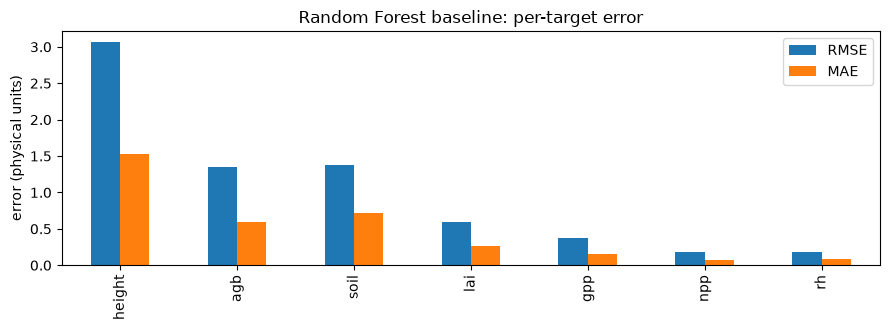

In [16]:
# Bar chart of per-target RMSE / MAE.
ax = tbl[['RMSE', 'MAE']].plot.bar(figsize=(9, 3.4))
ax.set_title('Random Forest baseline: per-target error'); ax.set_ylabel('error (physical units)')
plt.tight_layout(); plt.show()


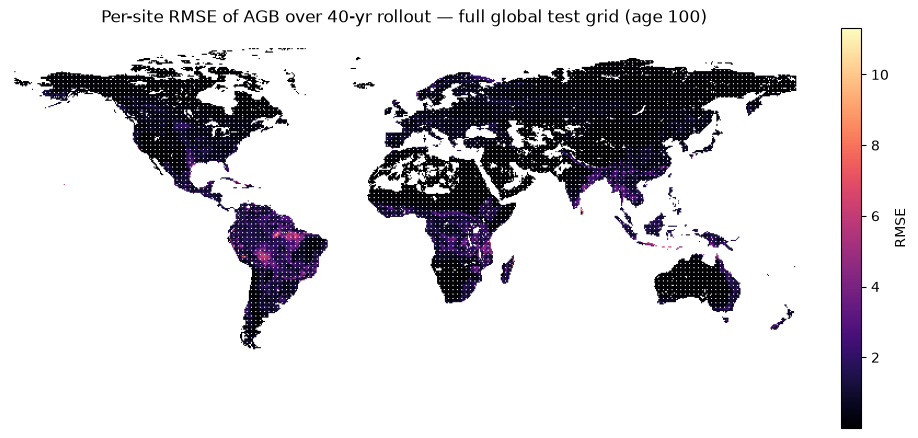

Mean / median site RMSE (AGB): 0.533 0.184


In [17]:
# Per-site error map over the FULL global test grid (the §1-② global-scale / downstream view).
# test8 above is the headline metric; here we visualize error across all 50,779 test.csv sites.
age = 100
Xann_g, Ydec_g = global_arrays(test_idx, [age])                     # (50779,40,136), (1,50779,41,7)
p_all, t_all = rollout_rf(rf, Xann_g, Ydec_g, ages=[age], verbose=False)   # (1, 50779, 40, 7)
p_seq, t_seq = p_all[0], t_all[0]                                   # (50779, 40, 7)
k = TREE_BAND.index('agb')
site_rmse = np.sqrt(np.mean((t_seq[:, :, k] - p_seq[:, :, k]) ** 2, axis=1))   # (50779,)

plt.figure(figsize=(11, 5.2))
im = plt.imshow(to_grid(site_rmse, idx=test_idx), cmap='magma', origin='upper')
plt.title(f'Per-site RMSE of AGB over 40-yr rollout — full global test grid (age {age})'); plt.axis('off')
plt.colorbar(im, fraction=0.025, label='RMSE'); plt.show()
print('Mean / median site RMSE (AGB):', round(np.nanmean(site_rmse),3), round(np.nanmedian(site_rmse),3))


## 7. Summary & next steps

We loaded the split, normalized with the provided statistics, mapped data onto the global grid,
trained a **Random Forest** one-step baseline (**saved** to `rf_baseline.joblib`), and evaluated it
with a **40-year autoregressive rollout** on the **test8** held-out set — then visualized per-site
error across the full global grid.

Because the rollout feeds the model its own forecasts, errors **accumulate** over the horizon; that
long-horizon **drift** is exactly what the benchmark deep models (DeepED, Transformer, Informer) are
designed to curb. See the challenge's other starter notebooks for calling a trained **DeepED**
emulator and for preparing a competition submission.

**Tips:** train in normalized space and report in physical units; **always evaluate autoregressively**
(feed predictions forward) and watch long-horizon **cumulative drift**, not just average RMSE.
